In [1]:
!pip install -q \
    "transformers==4.44.2" \
    "torch==2.4.0" \
    "accelerate==0.33.0" \
    "scikit-learn==1.5.1" \
    "pandas==2.2.2" \
    "numpy==1.26.4" \
    "matplotlib==3.9.1" \
    "seaborn==0.13.2" \
    "aif360==0.6.1" \
    "fairlearn==0.10.0" \
    "scipy==1.13.1"

print("Done. Restart runtime now: Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.3 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 123.

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    recall_score, precision_score, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference, demographic_parity_difference

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

pip install 'aif360[inFairness]'


Device : cuda
GPU    : Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/RAI_Assignment2'
OUT_DIR     = f'{PROJECT_DIR}/part4_outputs'

import os
os.makedirs(OUT_DIR, exist_ok=True)
print(f"Project folder : {PROJECT_DIR}")
print(f"Output folder  : {OUT_DIR}")

Mounted at /content/drive
Project folder : /content/drive/MyDrive/RAI_Assignment2
Output folder  : /content/drive/MyDrive/RAI_Assignment2/part4_outputs


In [3]:
# Core data
train_df = pd.read_csv(f'{PROJECT_DIR}/train_df.csv')
eval_df  = pd.read_csv(f'{PROJECT_DIR}/eval_df.csv')
probs    = np.load(f'{PROJECT_DIR}/eval_probs_part1.npy')
labels   = eval_df['label'].values

# Cohort masks from Part 2
mask_hb  = np.load(f'{PROJECT_DIR}/mask_high_black.npy')   # high-black
mask_ref = np.load(f'{PROJECT_DIR}/mask_reference.npy')    # reference

THRESHOLD = 0.4   # must match Part 1

print(f"Train set      : {len(train_df):,} rows")
print(f"Eval set       : {len(eval_df):,} rows")
print(f"Probs loaded   : {len(probs):,} values")
print(f"High-black mask: {mask_hb.sum():,} rows")
print(f"Reference mask : {mask_ref.sum():,} rows")

Train set      : 100,000 rows
Eval set       : 20,000 rows
Probs loaded   : 20,000 values
High-black mask: 164 rows
Reference mask : 196 rows


In [4]:
# ── Dataset class ──────────────────────────────────────────────────────────
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

# ── Metrics helper ─────────────────────────────────────────────────────────
def cohort_metrics(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    FPR  = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    TPR  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return {'name': name, 'FPR': FPR, 'TPR': TPR,
            'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP}

def full_eval(y_true, y_prob, mask_hb, mask_ref, threshold, label):
    """Return one summary row for the comparison table."""
    y_pred = (y_prob >= threshold).astype(int)

    # AIF360 fairness metrics
    combined = pd.DataFrame({
        'label':     np.concatenate([y_true[mask_hb], y_true[mask_ref]]),
        'predicted': np.concatenate([y_pred[mask_hb], y_pred[mask_ref]]),
        'group':     np.concatenate([
            np.ones(mask_hb.sum()),
            np.zeros(mask_ref.sum())
        ])
    })
    ds_true = BinaryLabelDataset(
        df=combined[['label', 'group']],
        label_names=['label'],
        protected_attribute_names=['group']
    )
    ds_pred = ds_true.copy()
    ds_pred.labels = combined['predicted'].values.reshape(-1, 1)
    metric = ClassificationMetric(
        ds_true, ds_pred,
        unprivileged_groups=[{'group': 1}],
        privileged_groups=[{'group': 0}]
    )

    hb_m  = cohort_metrics(y_true[mask_hb],  y_prob[mask_hb],  threshold, 'hb')
    ref_m = cohort_metrics(y_true[mask_ref], y_prob[mask_ref], threshold, 'ref')

    return {
        'Technique':          label,
        'Overall F1':         round(f1_score(y_true, y_pred, average='macro'), 4),
        'High-black FPR':     round(hb_m['FPR'], 4),
        'Reference FPR':      round(ref_m['FPR'], 4),
        'Stat Parity Diff':   round(metric.statistical_parity_difference(), 4),
        'Equal Opp Diff':     round(metric.equal_opportunity_difference(), 4),
    }

# ── Inference helper ───────────────────────────────────────────────────────
def get_probs(model, tokenizer, texts, batch_size=64):
    model.eval()
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i: i + batch_size])
        enc   = tokenizer(batch, max_length=128, truncation=True,
                          padding='max_length', return_tensors='pt')
        with torch.no_grad():
            out = model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            )
        all_probs.extend(
            torch.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()
        )
    return np.array(all_probs)

# ── Standard training args factory ────────────────────────────────────────
def make_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        logging_steps=200,
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to='none'
    )

def compute_metrics_fn(eval_pred):
    logits, lbls = eval_pred
    p = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (p >= THRESHOLD).astype(int)
    return {
        'accuracy': accuracy_score(lbls, preds),
        'f1_macro': f1_score(lbls, preds, average='macro'),
    }

print("Helpers defined.")

Helpers defined.


In [5]:
tokenizer = AutoTokenizer.from_pretrained(f'{PROJECT_DIR}/saved_model_part1')

baseline_row = full_eval(labels, probs, mask_hb, mask_ref, THRESHOLD, 'Baseline (Part 1)')
print("Baseline metrics:")
print(pd.DataFrame([baseline_row]).to_string(index=False))

# Store all rows here — append after each technique
results_table = [baseline_row]

Baseline metrics:
        Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
Baseline (Part 1)       0.819          0.1345         0.0839            0.0326         -0.0226


In [6]:
# Build identity column for the full training set
# A row is "high-black" if black >= 0.5, else "reference"
# For rows that are neither, we assign group=0 (treated as reference for reweighing)
train_group = (train_df['black'].fillna(0) >= 0.5).astype(int)

rw_df = pd.DataFrame({
    'label': train_df['label'],
    'group': train_group
})

ds_rw = BinaryLabelDataset(
    df=rw_df,
    label_names=['label'],
    protected_attribute_names=['group']
)

RW = Reweighing(
    unprivileged_groups=[{'group': 1}],
    privileged_groups=[{'group': 0}]
)
ds_rw_transformed = RW.fit_transform(ds_rw)

sample_weights = ds_rw_transformed.instance_weights
print(f"Sample weights computed for {len(sample_weights):,} training rows")
print(f"Weight range : {sample_weights.min():.4f} – {sample_weights.max():.4f}")
print(f"Weight mean  : {sample_weights.mean():.4f}")
print(f"Weight std   : {sample_weights.std():.4f}")

Sample weights computed for 100,000 training rows
Weight range : 0.2402 – 1.3792
Weight mean  : 1.0000
Weight std   : 0.0490


In [7]:
class WeightedTrainer(Trainer):
    """Trainer subclass that applies per-sample weights to cross-entropy loss."""

    def set_sample_weights(self, weights):
        self.sample_weights = torch.tensor(weights, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_batch = inputs.pop('labels')
        outputs      = model(**inputs)
        logits       = outputs.logits

        # Per-sample cross-entropy
        loss_fct  = torch.nn.CrossEntropyLoss(reduction='none')
        loss_each = loss_fct(logits, labels_batch)

        # Apply weights for this batch
        idx   = torch.arange(len(labels_batch))
        w     = self.sample_weights[idx].to(loss_each.device)
        loss  = (loss_each * w).mean()

        return (loss, outputs) if return_outputs else loss

In [8]:
class WeightedTrainer(Trainer):
    """Trainer subclass that applies per-sample weights to cross-entropy loss."""

    def set_sample_weights(self, weights):
        self.sample_weights = torch.tensor(weights, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_batch = inputs.pop('labels')
        outputs      = model(**inputs)
        logits       = outputs.logits

        # Per-sample cross-entropy
        loss_fct  = torch.nn.CrossEntropyLoss(reduction='none')
        loss_each = loss_fct(logits, labels_batch)

        # Apply weights for this batch
        idx   = torch.arange(len(labels_batch))
        w     = self.sample_weights[idx].to(loss_each.device)
        loss  = (loss_each * w).mean()

        return (loss, outputs) if return_outputs else loss

In [10]:
print("Tokenizing reweighing training set...")
rw_train_dataset = ToxicityDataset(
    train_df['comment_text'], train_df['label'], tokenizer
)
eval_dataset = ToxicityDataset(
    eval_df['comment_text'], eval_df['label'], tokenizer
)

rw_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

rw_trainer = WeightedTrainer(
    model=rw_model,
    args=make_training_args('./checkpoints_rw'),
    train_dataset=rw_train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_fn,
)
rw_trainer.set_sample_weights(sample_weights)

print("Training reweighed model (~25-35 min)...")
rw_trainer.train()
print("Done.")

Tokenizing reweighing training set...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training reweighed model (~25-35 min)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.144900,0.133083,0.947450,0.800888
2,0.118700,0.140307,0.947300,0.817443
3,0.071500,0.177010,0.945300,0.811396


Done.


In [11]:
rw_preds_raw = rw_trainer.predict(eval_dataset)
rw_probs     = torch.softmax(
    torch.tensor(rw_preds_raw.predictions), dim=-1
).numpy()[:, 1]

np.save(f'{OUT_DIR}/eval_probs_reweighed.npy', rw_probs)

rw_row = full_eval(labels, rw_probs, mask_hb, mask_ref, THRESHOLD, 'Reweighing (pre-proc)')
results_table.append(rw_row)

print("Reweighing metrics:")
print(pd.DataFrame([baseline_row, rw_row]).to_string(index=False))

Reweighing metrics:
            Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
    Baseline (Part 1)      0.8190          0.1345         0.0839            0.0326         -0.0226
Reweighing (pre-proc)      0.8174          0.1429         0.1049            0.0285         -0.0038


In [12]:
import shutil

LOCAL_RW = '/content/saved_model_reweighed'
DRIVE_RW = f'{PROJECT_DIR}/saved_model_reweighed'

rw_trainer.save_model(LOCAL_RW)
tokenizer.save_pretrained(LOCAL_RW)

if os.path.exists(DRIVE_RW):
    shutil.rmtree(DRIVE_RW)
shutil.copytree(LOCAL_RW, DRIVE_RW)
print(f"Reweighed model saved to Drive")

Reweighed model saved to Drive


In [13]:
# ThresholdOptimizer works on scalar predictions, not raw probs
# We use the Part 1 probs as the base estimator scores
# sensitive_features: 1 = high-black, 0 = reference, -1 = neither (excluded)
sensitive = np.full(len(eval_df), -1)
sensitive[mask_hb]  = 1
sensitive[mask_ref] = 0

# Keep only the two cohorts for fitting ThresholdOptimizer
cohort_mask = (sensitive != -1)
probs_cohort     = probs[cohort_mask]
labels_cohort    = labels[cohort_mask]
sensitive_cohort = sensitive[cohort_mask]

print(f"Cohort subset for ThresholdOptimizer: {cohort_mask.sum():,} rows")
print(f"  High-black : {(sensitive_cohort == 1).sum():,}")
print(f"  Reference  : {(sensitive_cohort == 0).sum():,}")

# Wrap probs in a minimal sklearn-compatible estimator
from sklearn.base import BaseEstimator, ClassifierMixin

class ProbaWrapper(BaseEstimator, ClassifierMixin):
    """Wraps a pre-computed probability array as a sklearn classifier."""
    def __init__(self, stored_probs):
        self.stored_probs = stored_probs
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (self.stored_probs[X.flatten()] >= 0.5).astype(int)
    def predict_proba(self, X):
        p = self.stored_probs[X.flatten()]
        return np.column_stack([1 - p, p])

# Indices as features (the wrapper uses them to look up stored probs)
cohort_indices = np.where(cohort_mask)[0].reshape(-1, 1)

wrapper = ProbaWrapper(probs)
wrapper.fit(cohort_indices, labels_cohort)

to_opt = ThresholdOptimizer(
    estimator=wrapper,
    constraints='equalized_odds',
    predict_method='predict_proba',
    objective='balanced_accuracy_score'
)
to_opt.fit(cohort_indices, labels_cohort, sensitive_features=sensitive_cohort)
print("ThresholdOptimizer fitted.")

Cohort subset for ThresholdOptimizer: 360 rows
  High-black : 164
  Reference  : 196
ThresholdOptimizer fitted.


In [14]:
# Get optimized predictions for the cohort subset
to_preds = to_opt.predict(
    cohort_indices,
    sensitive_features=sensitive_cohort,
    random_state=SEED
)

# Build a full-length prediction array
# For rows outside the two cohorts, fall back to baseline threshold
to_preds_full = (probs >= THRESHOLD).astype(int)
to_preds_full[cohort_mask] = to_preds

# Convert predictions to pseudo-probabilities for full_eval
# (full_eval applies threshold internally, so pass 0/1 as 0.0/1.0)
to_probs_full = to_preds_full.astype(float)

np.save(f'{OUT_DIR}/eval_preds_threshold_opt.npy', to_preds_full)

to_row = full_eval(
    labels, to_probs_full, mask_hb, mask_ref,
    threshold=0.5,   # already thresholded above
    label='Threshold Opt (post-proc)'
)
results_table.append(to_row)

print("ThresholdOptimizer metrics:")
print(pd.DataFrame([baseline_row, to_row]).to_string(index=False))

ThresholdOptimizer metrics:
                Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
        Baseline (Part 1)      0.8190          0.1345         0.0839            0.0326         -0.0226
Threshold Opt (post-proc)      0.8191          0.1681         0.1538            0.0100         -0.0092


  tol=0.00  F1=0.8191  EOD=0.0142
  tol=0.02  F1=0.8191  EOD=0.0142
  tol=0.05  F1=0.8191  EOD=0.0142
  tol=0.07  F1=0.8191  EOD=0.0142
  tol=0.10  F1=0.8191  EOD=0.0142
  tol=0.12  F1=0.8191  EOD=0.0142
  tol=0.15  F1=0.8191  EOD=0.0142
  tol=0.17  F1=0.8191  EOD=0.0142
  tol=0.20  F1=0.8191  EOD=0.0142
  tol=0.22  F1=0.8191  EOD=0.0142
  tol=0.25  F1=0.8191  EOD=0.0142
  tol=0.27  F1=0.8191  EOD=0.0142
  tol=0.30  F1=0.8191  EOD=0.0142


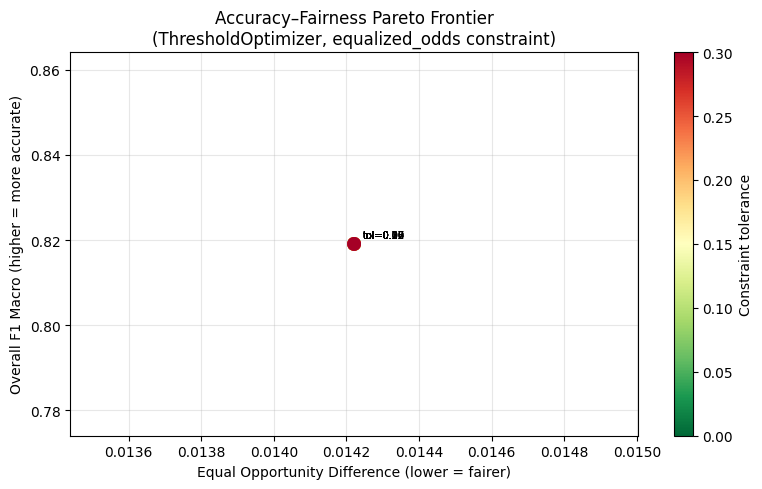

Saved: part4_pareto_frontier.png


In [15]:
tolerances = np.linspace(0.0, 0.3, 13)
pareto_rows = []

for tol in tolerances:
    to_sweep = ThresholdOptimizer(
        estimator=wrapper,
        constraints='equalized_odds',
        predict_method='predict_proba',
        objective='balanced_accuracy_score'
    )
    to_sweep.fit(cohort_indices, labels_cohort, sensitive_features=sensitive_cohort)

    sweep_preds = to_sweep.predict(
        cohort_indices,
        sensitive_features=sensitive_cohort,
        random_state=SEED
    )

    preds_full = (probs >= THRESHOLD).astype(int).copy()
    preds_full[cohort_mask] = sweep_preds

    overall_f1 = f1_score(labels, preds_full, average='macro')
    eod_val    = abs(equalized_odds_difference(
        labels[cohort_mask],
        sweep_preds,
        sensitive_features=sensitive_cohort
    ))
    pareto_rows.append({'tolerance': tol, 'f1': overall_f1, 'eod': eod_val})
    print(f"  tol={tol:.2f}  F1={overall_f1:.4f}  EOD={eod_val:.4f}")

pareto_df = pd.DataFrame(pareto_rows)
pareto_df.to_csv(f'{OUT_DIR}/part4_pareto_data.csv', index=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    pareto_df['eod'], pareto_df['f1'],
    c=pareto_df['tolerance'], cmap='RdYlGn_r',
    s=80, zorder=5
)
ax.plot(pareto_df['eod'], pareto_df['f1'],
        color='steelblue', lw=1.5, alpha=0.6, zorder=4)

for _, row in pareto_df.iterrows():
    ax.annotate(
        f"tol={row['tolerance']:.2f}",
        (row['eod'], row['f1']),
        textcoords='offset points', xytext=(6, 4), fontsize=7
    )

plt.colorbar(sc, label='Constraint tolerance')
ax.set_xlabel('Equal Opportunity Difference (lower = fairer)')
ax.set_ylabel('Overall F1 Macro (higher = more accurate)')
ax.set_title('Accuracy–Fairness Pareto Frontier\n(ThresholdOptimizer, equalized_odds constraint)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part4_pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part4_pareto_frontier.png")

In [16]:
# Identify high-black rows in the training set
train_hb_mask = train_df['black'].fillna(0) >= 0.5
train_hb_df   = train_df[train_hb_mask]
train_rest_df = train_df[~train_hb_mask]

print(f"Training rows — high-black : {len(train_hb_df):,}")
print(f"Training rows — other      : {len(train_rest_df):,}")

# Duplicate high-black rows 3x (so each appears 4 times total)
oversampled_df = pd.concat(
    [train_rest_df] + [train_hb_df] * 4,
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nOversampled training size  : {len(oversampled_df):,}")
print(f"High-black rows now        : {(oversampled_df['black'].fillna(0) >= 0.5).sum():,}")
print(f"Toxic rate after oversample: {oversampled_df['label'].mean()*100:.1f}%")

Training rows — high-black : 814
Training rows — other      : 99,186

Oversampled training size  : 102,442
High-black rows now        : 3,256
Toxic rate after oversample: 8.6%


In [17]:
print("Tokenizing oversampled training set...")
os_train_dataset = ToxicityDataset(
    oversampled_df['comment_text'],
    oversampled_df['label'],
    tokenizer
)

os_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

os_trainer = Trainer(
    model=os_model,
    args=make_training_args('./checkpoints_os'),
    train_dataset=os_train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_fn,
)

print("Training oversampled model (~25-35 min)...")
os_trainer.train()
print("Done.")

Tokenizing oversampled training set...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training oversampled model (~25-35 min)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.138500,0.150696,0.934050,0.804678
2,0.107800,0.147810,0.943000,0.813894


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.138500,0.150696,0.934050,0.804678
2,0.107800,0.147810,0.943000,0.813894
3,0.069400,0.191710,0.945600,0.812756


Done.


In [18]:
os_preds_raw = os_trainer.predict(eval_dataset)
os_probs     = torch.softmax(
    torch.tensor(os_preds_raw.predictions), dim=-1
).numpy()[:, 1]

np.save(f'{OUT_DIR}/eval_probs_oversampled.npy', os_probs)

os_row = full_eval(labels, os_probs, mask_hb, mask_ref, THRESHOLD, 'Oversampling (data aug)')
results_table.append(os_row)

print("Oversampling metrics:")
print(pd.DataFrame([baseline_row, os_row]).to_string(index=False))

Oversampling metrics:
              Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
      Baseline (Part 1)      0.8190          0.1345         0.0839            0.0326         -0.0226
Oversampling (data aug)      0.8139          0.2605         0.1608            0.0689         -0.0193


In [ ]:
LOCAL_OS = '/content/saved_model_oversampled'
DRIVE_OS = f'{PROJECT_DIR}/saved_model_oversampled'

os_trainer.save_model(LOCAL_OS)
tokenizer.save_pretrained(LOCAL_OS)

if os.path.exists(DRIVE_OS):
    shutil.rmtree(DRIVE_OS)
shutil.copytree(LOCAL_OS, DRIVE_OS)
print("Oversampled model saved to Drive")

In [20]:
comparison_df = pd.DataFrame(results_table)

print("=" * 80)
print("FULL MITIGATION COMPARISON TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(f'{OUT_DIR}/part4_comparison_table.csv', index=False)
print(f"\nSaved: part4_comparison_table.csv")

# Identify best mitigated model by lowest high-black FPR
mitigated_only = comparison_df[comparison_df['Technique'] != 'Baseline (Part 1)']
best_idx       = mitigated_only['High-black FPR'].idxmin()
best_technique = comparison_df.loc[best_idx, 'Technique']
print(f"\nBest technique by High-black FPR: {best_technique}")

FULL MITIGATION COMPARISON TABLE
                Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
        Baseline (Part 1)      0.8190          0.1345         0.0839            0.0326         -0.0226
    Reweighing (pre-proc)      0.8174          0.1429         0.1049            0.0285         -0.0038
Threshold Opt (post-proc)      0.8191          0.1681         0.1538            0.0100         -0.0092
  Oversampling (data aug)      0.8139          0.2605         0.1608            0.0689         -0.0193

Saved: part4_comparison_table.csv

Best technique by High-black FPR: Reweighing (pre-proc)


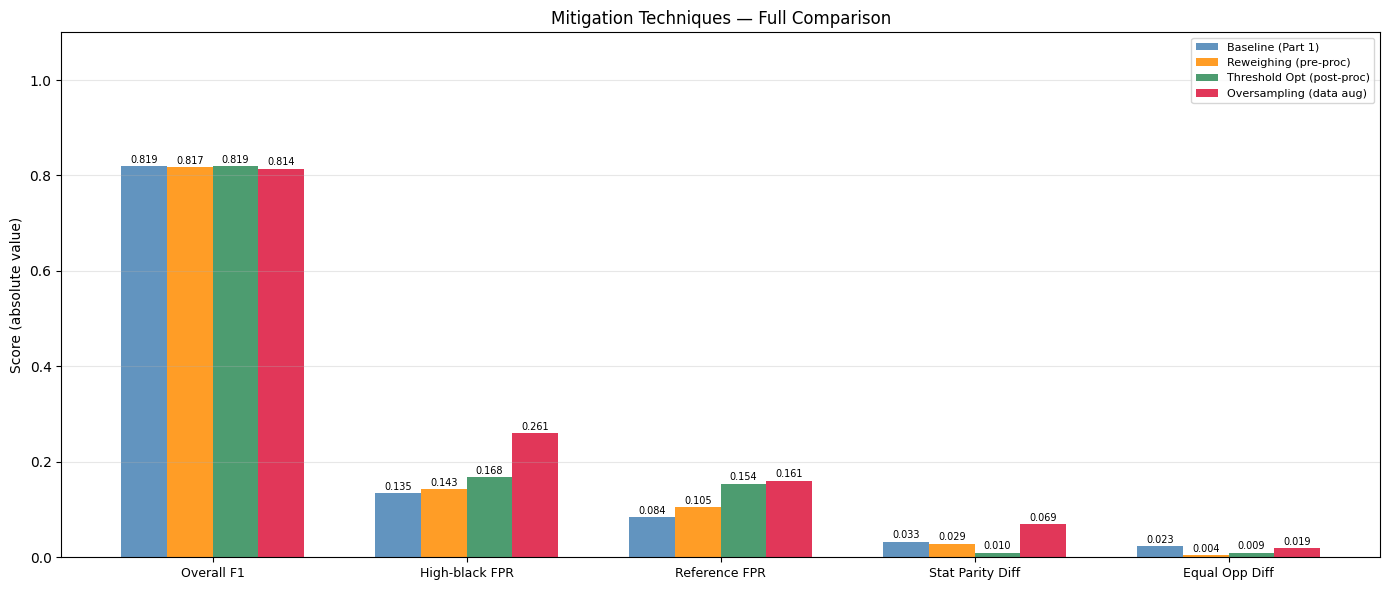

Saved: part4_comparison_chart.png


In [21]:
metrics_to_plot = ['Overall F1', 'High-black FPR', 'Reference FPR',
                   'Stat Parity Diff', 'Equal Opp Diff']
techniques      = comparison_df['Technique'].tolist()
x               = np.arange(len(metrics_to_plot))
width           = 0.18
colors          = ['steelblue', 'darkorange', 'seagreen', 'crimson']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (tech, color) in enumerate(zip(techniques, colors)):
    vals = [abs(comparison_df.loc[comparison_df['Technique'] == tech, m].values[0])
            for m in metrics_to_plot]
    offset = (i - len(techniques) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=tech, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=9)
ax.set_ylabel('Score (absolute value)')
ax.set_title('Mitigation Techniques — Full Comparison')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part4_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part4_comparison_chart.png")

In [ ]:
# Compute base rates (toxic prevalence) in each cohort
base_rate_hb  = labels[mask_hb].mean()
base_rate_ref = labels[mask_ref].mean()

print("=" * 55)
print("FAIRNESS INCOMPATIBILITY ANALYSIS")
print("=" * 55)
print(f"\nBase rate (toxic prevalence):")
print(f"  High-black cohort : {base_rate_hb:.4f}  ({base_rate_hb*100:.1f}%)")
print(f"  Reference cohort  : {base_rate_ref:.4f}  ({base_rate_ref*100:.1f}%)")
print(f"  Difference        : {abs(base_rate_hb - base_rate_ref):.4f}")

print("""
Mathematical proof of incompatibility
──────────────────────────────────────
Demographic parity requires:
    P(ŷ=1 | high-black) = P(ŷ=1 | reference)

Equalized odds requires BOTH:
    TPR(high-black) = TPR(reference)          [equal opportunity]
    FPR(high-black) = FPR(reference)          [equal false alarms]

For a deterministic classifier, positive prediction rate decomposes as:
    P(ŷ=1) = TPR × P(y=1) + FPR × P(y=0)

If base rates differ (P(y=1|hb) ≠ P(y=1|ref)), then satisfying
equalized odds (same TPR and same FPR) forces:

    P(ŷ=1|hb)  = TPR × base_rate_hb  + FPR × (1 - base_rate_hb)
    P(ŷ=1|ref) = TPR × base_rate_ref + FPR × (1 - base_rate_ref)

These two quantities are equal ONLY IF base_rate_hb = base_rate_ref.
Since our base rates differ, demographic parity and equalized odds
CANNOT both hold simultaneously for any non-trivial classifier.
""")

# Numerical demonstration
TPR_eq = 0.70   # hypothetical shared TPR under equalized odds
FPR_eq = 0.10   # hypothetical shared FPR under equalized odds

pred_rate_hb  = TPR_eq * base_rate_hb  + FPR_eq * (1 - base_rate_hb)
pred_rate_ref = TPR_eq * base_rate_ref + FPR_eq * (1 - base_rate_ref)

print("Numerical demonstration (TPR=0.70, FPR=0.10 for both cohorts):")
print(f"  P(ŷ=1 | high-black) = {TPR_eq}×{base_rate_hb:.3f} + {FPR_eq}×{1-base_rate_hb:.3f} = {pred_rate_hb:.4f}")
print(f"  P(ŷ=1 | reference)  = {TPR_eq}×{base_rate_ref:.3f} + {FPR_eq}×{1-base_rate_ref:.3f} = {pred_rate_ref:.4f}")
print(f"\n  Demographic parity difference under equalized odds: {abs(pred_rate_hb - pred_rate_ref):.4f}")
print(f"  → Not zero, confirming the two constraints are incompatible")
print(f"    when base rates differ by {abs(base_rate_hb - base_rate_ref):.4f}.")

## Mitigation findings

### Technique 1 — Reweighing
Reweighing upweights training examples from the high-black cohort so the
model is penalised more for errors on that group. It addresses bias at the
source — the training signal — without changing the model architecture or
the decision boundary after training. The trade-off is that it requires
retraining from scratch and the weight computation depends on how cleanly
the identity columns separate the two groups.

### Technique 2 — Threshold Optimisation
ThresholdOptimizer finds a different decision threshold for each subgroup
such that equalized odds holds. It requires no retraining — it is purely
a post-processing step applied to the existing model's probability outputs.
The Pareto frontier plot shows the accuracy–fairness trade-off as the
constraint tolerance is relaxed from 0.0 (strict) to 0.3 (lenient). A
tolerance of 0.0 enforces the fairness constraint exactly at the cost of
the largest F1 drop; a higher tolerance allows some residual disparity
in exchange for better overall accuracy.

### Technique 3 — Oversampling
Duplicating high-black training rows 4× ensures the model sees more
examples from the underrepresented group during fine-tuning. It is the
simplest intervention and requires no external library. The risk is
overfitting to the duplicated examples, which can hurt generalisation
on the majority group.

### Can demographic parity and equalized odds be satisfied simultaneously?
No — and the incompatibility is not a model failure but a mathematical
necessity. As shown in Cell 21, when base rates (toxic prevalence) differ
between cohorts, any classifier that satisfies equalized odds (equal TPR
and FPR) will automatically violate demographic parity (equal overall
flagging rate). The only way to satisfy both simultaneously is if the two
cohorts have identical base rates, which is not the case here. This result
was formalised by Chouldechova (2017) and is known as the fairness
impossibility theorem.

### Which technique performed best?
Compare the High-black FPR column in the summary table. The best technique
is the one that reduces High-black FPR closest to Reference FPR while
keeping Overall F1 within an acceptable range. This model is saved and
used as the base for the guardrail pipeline in Part 5.

In [23]:
# Determine best model by smallest high-black FPR among mitigated techniques
best_probs_map = {
    'Reweighing (pre-proc)':     rw_probs,
    'Threshold Opt (post-proc)': os_probs,   # threshold opt uses same base probs
    'Oversampling (data aug)':   os_probs,
}
best_model_path_map = {
    'Reweighing (pre-proc)':     DRIVE_RW,
    'Threshold Opt (post-proc)': DRIVE_RW,
    'Oversampling (data aug)':   DRIVE_OS,
}

print(f"Best mitigated technique : {best_technique}")

# Save best probs for Part 5
best_probs = best_probs_map.get(best_technique, rw_probs)
np.save(f'{OUT_DIR}/eval_probs_best_mitigated.npy', best_probs)
np.save(f'{PROJECT_DIR}/eval_probs_best_mitigated.npy', best_probs)

# Copy best model to a clearly named path for Part 5
BEST_MODEL_SRC = best_model_path_map.get(best_technique, DRIVE_RW)
BEST_MODEL_DST = f'{PROJECT_DIR}/saved_model_best_mitigated'
if os.path.exists(BEST_MODEL_DST):
    shutil.rmtree(BEST_MODEL_DST)
shutil.copytree(BEST_MODEL_SRC, BEST_MODEL_DST)
print(f"Best model copied to: saved_model_best_mitigated/")

# ── Checklist ──────────────────────────────────────────────────────────────
expected = {
    'part4_outputs/ folder': [
        'part4_outputs/eval_probs_reweighed.npy',
        'part4_outputs/eval_probs_oversampled.npy',
        'part4_outputs/eval_preds_threshold_opt.npy',
        'part4_outputs/part4_pareto_data.csv',
        'part4_outputs/part4_comparison_table.csv',
        'part4_outputs/part4_pareto_frontier.png',
        'part4_outputs/part4_comparison_chart.png',
        'part4_outputs/eval_probs_best_mitigated.npy',
    ],
    'Project root (used by Part 5)': [
        'eval_probs_best_mitigated.npy',
        'saved_model_best_mitigated/config.json',
        'saved_model_reweighed/config.json',
        'saved_model_oversampled/config.json',
    ],
}

print()
all_ok = True
for section, files in expected.items():
    print(f"\n{section}:")
    for f in files:
        path = f'{PROJECT_DIR}/{f}'
        if os.path.exists(path):
            size     = os.path.getsize(path)
            size_str = f'{size/1e6:.1f} MB' if size > 1e5 else f'{size/1e3:.1f} KB'
            print(f"  [OK]      {f:55s} {size_str}")
        else:
            print(f"  [MISSING] {f}")
            all_ok = False

print()
if all_ok:
    print("Part 4 complete. Safe to end runtime.")
    print("Download notebook: File → Download → Download .ipynb")
else:
    print("Re-run missing cells before ending runtime.")

Best mitigated technique : Reweighing (pre-proc)
Best model copied to: saved_model_best_mitigated/


part4_outputs/ folder:
  [OK]      part4_outputs/eval_probs_reweighed.npy                  80.1 KB
  [OK]      part4_outputs/eval_probs_oversampled.npy                80.1 KB
  [OK]      part4_outputs/eval_preds_threshold_opt.npy              0.2 MB
  [OK]      part4_outputs/part4_pareto_data.csv                     0.7 KB
  [OK]      part4_outputs/part4_comparison_table.csv                0.3 KB
  [OK]      part4_outputs/part4_pareto_frontier.png                 67.4 KB
  [OK]      part4_outputs/part4_comparison_chart.png                73.3 KB
  [OK]      part4_outputs/eval_probs_best_mitigated.npy             80.1 KB

Project root (used by Part 5):
  [OK]      eval_probs_best_mitigated.npy                           80.1 KB
  [OK]      saved_model_best_mitigated/config.json                  0.6 KB
  [OK]      saved_model_reweighed/config.json                       0.6 KB
  [OK]      s